<a href="https://colab.research.google.com/github/OuyangXuelili/BigData/blob/main/EDA_Amazon_2023_Electronics_Dataset_merged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#NOTE: file download from a 'volatile' Google Drive link, so the link may not work in the future.

In [1]:
import pandas as pd
import seaborn as sns
import dask.dataframe as dd
import polars as pl
import matplotlib.pyplot as plt

In [2]:
%pip install pyarrow fastparquet gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.6 MB/s eta 0:00:00


In [2]:
import gdown

file_id = '1KPR0eLs6VjVGk-g1YFskzfydH1sPBRFa'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'data.parquet'



In [ ]:
# Download the file to the local Colab instance => Main Bottleneck
gdown.download(url, output, quiet=False)



In [3]:
review_metadata_combined = pl.scan_parquet(output)

In [4]:
review_metadata_combined.head(10).collect()

parent_asin,user_id,rating,text,timestamp,helpful_vote,verified_purchase,title,main_category,average_rating,rating_number,price_clean
str,str,i64,str,datetime[ns],i64,bool,str,str,f64,i64,f32
"""B07DNTNB17""","""AHKT6ENN4FJSYRJNDDHTPCEAF34Q""",4,"""great price works great only…",2012-09-17 22:13:55,0,true,"""Monoprice 103639 Banana Bindin…","""Home Audio & Theater""",4.6,2409,6.48
"""B09PHSBJGX""","""AFQKCEQFJXTP56VBI23CBSLDMLPA""",1,"""it broke after less than a mon…",2022-09-24 15:14:31.455,0,true,"""Female Component to HDMI Conve…","""All Electronics""",4.1,215,17.98
"""B075VM76MV""","""AFQKCEQFJXTP56VBI23CBSLDMLPA""",4,"""the price was right and it doe…",2021-05-29 15:16:10.689,1,true,"""EMART Photography Backdrop Con…","""Camera & Photo""",4.6,2043,104.989998
"""B074CPK9SB""","""AFQKCEQFJXTP56VBI23CBSLDMLPA""",5,"""it worked and was plenty fast …",2015-01-31 04:38:48,0,true,"""SanDisk 32GB Cruzer USB 2.0 Fl…","""All Electronics""",4.6,11189,null
"""B001EBDZE2""","""AFQKCEQFJXTP56VBI23CBSLDMLPA""",3,"""i bought this so that i could …",2009-07-08 13:20:32,2,true,"""Underwater Case for the Follow…","""Camera & Photo""",3.5,2,null
"""B0987D7NZJ""","""AETB6WOKWQDYHMGXOP2IWER5DCYA""",1,"""i bought a 2 pack of these cab…",2021-09-26 12:48:52.117,1,true,"""Yeung Qee 3.5mm Male to Male A…","""Industrial & Scientific""",4.4,89,7.99
"""B001O9CK2M""","""AFPDOWXX7QGOOB2ECJBIGET46POA""",5,"""extremely happy with this stan…",2010-12-01 13:24:52,0,false,"""Walker Edison 42-Inch 4-in-1 T…","""Amazon Home""",4.5,354,null
"""B00EFEWQ5E""","""AHKHG3PYJ47MSKRTBK3LNDO6S47Q""",5,"""great value for 3 protectors f…",2015-09-14 21:02:40,0,true,"""Supershieldz (3 Pack) Designed…","""Computers""",4.4,274,7.99
"""B018H03UCO""","""AGYEIEAIZUES4ZTQENXXCCOS7FSA""",5,"""i bought two of these in diffe…",2016-01-28 04:25:24,0,true,"""RCA Voyager 2 II 7"" inch Table…","""Computers""",5.0,1,null


#Tallying and summarizing whole dataset
Polars allow efficient querying of the large, combined dataset - without which your Colab instance will crash!

##NUMERIC ONLY

In [5]:
import polars.selectors as cs


In [6]:
numeric_col_list = review_metadata_combined.select(
    cs.numeric()
  ).collect_schema().names()
print(numeric_col_list)

['rating', 'helpful_vote', 'average_rating', 'rating_number', 'price_clean']


###Inspect missing and invalid data

In [7]:
# Create the calculation as part of the plan
null_count_df = review_metadata_combined.select(
    pl.col(numeric_col_list).null_count()
).collect()

print(null_count_df)

shape: (1, 5)
┌────────┬──────────────┬────────────────┬───────────────┬─────────────┐
│ rating ┆ helpful_vote ┆ average_rating ┆ rating_number ┆ price_clean │
│ ---    ┆ ---          ┆ ---            ┆ ---           ┆ ---         │
│ u32    ┆ u32          ┆ u32            ┆ u32           ┆ u32         │
╞════════╪══════════════╪════════════════╪═══════════════╪═════════════╡
│ 0      ┆ 0            ┆ 0              ┆ 0             ┆ 16425380    │
└────────┴──────────────┴────────────────┴───────────────┴─────────────┘


In [8]:
helpful_count_sub_zero = review_metadata_combined.filter(pl.col("helpful_vote") < 0)
helpful_count_sub_zero.collect()

parent_asin,user_id,rating,text,timestamp,helpful_vote,verified_purchase,title,main_category,average_rating,rating_number,price_clean
str,str,i64,str,datetime[ns],i64,bool,str,str,f64,i64,f32
"""B082X3H6P9""","""AEVZGLYSS3CBRF7KAO3ZDKZPFMCQ""",5,"""i have had a previous range ex…",2020-05-11 14:49:30.253,-4,true,"""rockspace WiFi Repeater - Dual…","""All Electronics""",3.8,2402,null
"""B0B2RK874T""","""AHFWJG5A5X2Z6HWU6YM4ZTO5BVCA""",5,"""just what i needed for coding …",2021-07-03 23:44:33.555,-1,true,"""New Mobile Pixels Duex Max 14.…","""Computers""",4.0,348,329.98999
"""B09M8DYH1B""","""AGCSSPVU3FJ7IOQ5T7R7RDP5IG7Q""",5,"""or maybe im easy to pleasebr b…",2021-04-29 21:15:20.197,-2,true,"""UPERFECT Portable Monitor 18.5…","""Computers""",4.6,707,299.98999
"""B078162HNC""","""AFGXFHGZ7NVPJNGQLLIACS2IUYXQ""",5,"""its so helpful in charging ver…",2019-01-12 23:34:42.365,-1,true,"""POWRUI Multi Wall Outlet Adapt…","""All Electronics""",4.7,12256,null


In [9]:
review_metadata_combined = review_metadata_combined.with_columns(
    pl.when((pl.col("helpful_vote") < 0) | (pl.col("helpful_vote").is_null()))
    .then(0)
    .otherwise(pl.col("helpful_vote"))
    .alias("helpful_vote")
)

In [13]:
# Calculate summary stats for price_clean specifically by excluding nulls from the aggregation
# price_non_null_summary = (
#     review_metadata_combined
#     .select(
#         pl.col("price_clean").drop_nulls()
#     )
#     .select(
#         pl.mean("price_clean").alias("price_mean"),
#         pl.median("price_clean").alias("price_median"),
#         pl.std("price_clean").alias("price_std"),
#         pl.min("price_clean").alias("price_min"),
#         pl.max("price_clean").alias("price_max")
#     )
#     .collect()
# )

# print("Summary statistics for price_clean (excluding NaNs):")
# print(price_non_null_summary)

In [10]:
mean_stats = (
    review_metadata_combined
    .select(
        cs.numeric().mean().name.suffix("_mean"),
    )
    .collect(streaming=True)
)
print(mean_stats)

/tmp/ipykernel_62436/1502865424.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (1, 5)
┌─────────────┬───────────────────┬─────────────────────┬────────────────────┬──────────────────┐
│ rating_mean ┆ helpful_vote_mean ┆ average_rating_mean ┆ rating_number_mean ┆ price_clean_mean │
│ ---         ┆ ---               ┆ ---                 ┆ ---                ┆ ---              │
│ f64         ┆ f64               ┆ f64                 ┆ f64                ┆ f32              │
╞═════════════╪═══════════════════╪═════════════════════╪════════════════════╪══════════════════╡
│ 4.04049     ┆ 1.203934          ┆ 4.268229            ┆ 21244.223445       ┆ 73.370163        │
└─────────────┴───────────────────┴─────────────────────┴────────────────────┴──────────────────┘


In [11]:
median_stats = (
    review_metadata_combined
    .select(

        cs.numeric().median().name.suffix("_median")
    )
    .collect(streaming=True)
)
print(median_stats)

/tmp/ipykernel_62436/196128569.py:7: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (1, 5)
┌───────────────┬────────────────────┬────────────────────┬────────────────────┬───────────────────┐
│ rating_median ┆ helpful_vote_media ┆ average_rating_med ┆ rating_number_medi ┆ price_clean_media │
│ ---           ┆ n                  ┆ ian                ┆ an                 ┆ n                 │
│ f64           ┆ ---                ┆ ---                ┆ ---                ┆ ---               │
│               ┆ f64                ┆ f64                ┆ f64                ┆ f32               │
╞═══════════════╪════════════════════╪════════════════════╪════════════════════╪═══════════════════╡
│ 5.0           ┆ 0.0                ┆ 4.4                ┆ 1261.0             ┆ 26.99             │
└───────────────┴────────────────────┴────────────────────┴────────────────────┴───────────────────┘


In [12]:
max_stats = (
    review_metadata_combined
    .select(
        cs.numeric().max().name.suffix("_max")
    )
    .collect(streaming=True)
)
print(max_stats)

/tmp/ipykernel_62436/2108042290.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (1, 5)
┌────────────┬──────────────────┬────────────────────┬───────────────────┬─────────────────┐
│ rating_max ┆ helpful_vote_max ┆ average_rating_max ┆ rating_number_max ┆ price_clean_max │
│ ---        ┆ ---              ┆ ---                ┆ ---               ┆ ---             │
│ i64        ┆ i64              ┆ f64                ┆ i64               ┆ f32             │
╞════════════╪══════════════════╪════════════════════╪═══════════════════╪═════════════════╡
│ 5          ┆ 46841            ┆ 5.0                ┆ 1034896           ┆ 44630.0         │
└────────────┴──────────────────┴────────────────────┴───────────────────┴─────────────────┘


In [13]:
# # Returns an Index object of column names
# numeric_cols = review_metadata_combined.select_dtypes(include=['number']).columns

# # If you need them as a standard Python list
# numeric_cols_list = numeric_cols.tolist()

# print(numeric_cols_list)

In [14]:
#min value of each numeric col
min_stats = (
    review_metadata_combined
    .select(
        cs.numeric().min().name.suffix("_min")
    )
    .collect(streaming=True)
)
print(min_stats)

/tmp/ipykernel_62436/3445037603.py:7: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (1, 5)
┌────────────┬──────────────────┬────────────────────┬───────────────────┬─────────────────┐
│ rating_min ┆ helpful_vote_min ┆ average_rating_min ┆ rating_number_min ┆ price_clean_min │
│ ---        ┆ ---              ┆ ---                ┆ ---               ┆ ---             │
│ i64        ┆ i64              ┆ f64                ┆ i64               ┆ f32             │
╞════════════╪══════════════════╪════════════════════╪═══════════════════╪═════════════════╡
│ 0          ┆ 0                ┆ 1.0                ┆ 1                 ┆ 0.01            │
└────────────┴──────────────────┴────────────────────┴───────────────────┴─────────────────┘


In [15]:
#std value of each numeric col
std_stats = (
    review_metadata_combined
    .select(
        cs.numeric().std().name.suffix("_std")
    )
    .collect(streaming=True)
)
print(std_stats)

/tmp/ipykernel_62436/3323440480.py:7: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (1, 5)
┌────────────┬──────────────────┬────────────────────┬───────────────────┬─────────────────┐
│ rating_std ┆ helpful_vote_std ┆ average_rating_std ┆ rating_number_std ┆ price_clean_std │
│ ---        ┆ ---              ┆ ---                ┆ ---               ┆ ---             │
│ f64        ┆ f64              ┆ f64                ┆ f64               ┆ f32             │
╞════════════╪══════════════════╪════════════════════╪═══════════════════╪═════════════════╡
│ 1.442087   ┆ 23.835233        ┆ 0.418806           ┆ 83820.55722       ┆ 177.613419      │
└────────────┴──────────────────┴────────────────────┴───────────────────┴─────────────────┘


In [16]:
#1st quartile value of each numeric col
Q1_stats = (
    review_metadata_combined
    .select(
        cs.numeric().quantile(0.25).name.suffix("_Q1")
    )
    .collect(streaming=True)
)
print(Q1_stats)

/tmp/ipykernel_62436/3070771918.py:7: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (1, 5)
┌───────────┬─────────────────┬───────────────────┬──────────────────┬────────────────┐
│ rating_Q1 ┆ helpful_vote_Q1 ┆ average_rating_Q1 ┆ rating_number_Q1 ┆ price_clean_Q1 │
│ ---       ┆ ---             ┆ ---               ┆ ---              ┆ ---            │
│ f64       ┆ f64             ┆ f64               ┆ f64              ┆ f32            │
╞═══════════╪═════════════════╪═══════════════════╪══════════════════╪════════════════╡
│ 3.0       ┆ 0.0             ┆ 4.1               ┆ 207.0            ┆ 14.89          │
└───────────┴─────────────────┴───────────────────┴──────────────────┴────────────────┘


In [17]:
#3rd Quartile value of each numeric col
Q3_stats = (
    review_metadata_combined
    .select(
        cs.numeric().quantile(0.75).name.suffix("_Q3")
    )
    .collect(streaming=True)
)
print(Q3_stats)

/tmp/ipykernel_62436/1781863602.py:7: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (1, 5)
┌───────────┬─────────────────┬───────────────────┬──────────────────┬────────────────┐
│ rating_Q3 ┆ helpful_vote_Q3 ┆ average_rating_Q3 ┆ rating_number_Q3 ┆ price_clean_Q3 │
│ ---       ┆ ---             ┆ ---               ┆ ---              ┆ ---            │
│ f64       ┆ f64             ┆ f64               ┆ f64              ┆ f32            │
╞═══════════╪═════════════════╪═══════════════════╪══════════════════╪════════════════╡
│ 5.0       ┆ 0.0             ┆ 4.6               ┆ 7386.0           ┆ 69.889999      │
└───────────┴─────────────────┴───────────────────┴──────────────────┴────────────────┘


In [18]:
#95% Quartile value of each numeric col
percentile_95th_stats = (
    review_metadata_combined
    .select(
        cs.numeric().quantile(0.95).name.suffix("_pcnt_95")
    )
    .collect(streaming=True)
)
print(percentile_95th_stats)

/tmp/ipykernel_62436/3016917351.py:7: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


shape: (1, 5)
┌────────────────┬────────────────────┬────────────────────┬───────────────────┬───────────────────┐
│ rating_pcnt_95 ┆ helpful_vote_pcnt_ ┆ average_rating_pcn ┆ rating_number_pcn ┆ price_clean_pcnt_ │
│ ---            ┆ 95                 ┆ t_95               ┆ t_95              ┆ 95                │
│ f64            ┆ ---                ┆ ---                ┆ ---               ┆ ---               │
│                ┆ f64                ┆ f64                ┆ f64               ┆ f32               │
╞════════════════╪════════════════════╪════════════════════╪═══════════════════╪═══════════════════╡
│ 5.0            ┆ 4.0                ┆ 4.7                ┆ 95902.0           ┆ 269.950012        │
└────────────────┴────────────────────┴────────────────────┴───────────────────┴───────────────────┘


In [19]:
#compile summary of numerical data in a nested dict
summary_stats = {}
for i in numeric_col_list:
    summary_stats[i] = {}
summary_stats

{'rating': {},
 'helpful_vote': {},
 'average_rating': {},
 'rating_number': {},
 'price_clean': {}}

Handling missing prices


In [20]:
# price_non_null_summary = (
#     review_metadata_combined
#     .select(
#         pl.col("price_clean").drop_nulls()
#     )
#     .select(
#         pl.col("price_clean").mean().name.suffix("_mean"),
#         pl.col("price_clean").median().name.suffix("_Q2"),
#         pl.col("price_clean").min().name.suffix("_min"),
#         pl.col("price_clean").max().name.suffix("_max"),
#         pl.col("price_clean").std().name.suffix("_std"),
#         pl.col("price_clean").quantile(0.25).name.suffix("_Q1"),
#         pl.col("price_clean").quantile(0.75).name.suffix("_Q3"),
#         pl.col("price_clean").quantile(0.95).name.suffix("_pcnt_95"),
#     )
#     .collect()
# )

# print("Summary statistics for price_clean (excluding NaNs):")
#print(price_non_null_summary['price_max'].item())

Print summary

In [21]:
import json

for col in numeric_col_list:
    summary_stats[col]['mean'] = mean_stats[f'{col}_mean'][0]
    summary_stats[col]['std'] = std_stats[f'{col}_std'][0]
    summary_stats[col]['min'] = min_stats[f'{col}_min'][0]
    summary_stats[col]['max'] = max_stats[f'{col}_max'][0]
    summary_stats[col]['Q1'] = Q1_stats[f'{col}_Q1'][0]
    summary_stats[col]['Q2'] = median_stats[f'{col}_median'][0]
    summary_stats[col]['Q3'] = Q3_stats[f'{col}_Q3'][0]
    summary_stats[col]['pcnt_95'] = percentile_95th_stats[f'{col}_pcnt_95'][0]

# Using json.dumps to print with indentation without sorting keys
print(json.dumps(summary_stats, indent=4))

{
    "rating": {
        "mean": 4.040490381448765,
        "std": 1.4420867313078096,
        "min": 0,
        "max": 5,
        "Q1": 3.0,
        "Q2": 5.0,
        "Q3": 5.0,
        "pcnt_95": 5.0
    },
    "helpful_vote": {
        "mean": 1.2039344700037764,
        "std": 23.835232623685435,
        "min": 0,
        "max": 46841,
        "Q1": 0.0,
        "Q2": 0.0,
        "Q3": 0.0,
        "pcnt_95": 4.0
    },
    "average_rating": {
        "mean": 4.268229039645291,
        "std": 0.41880553117460023,
        "min": 1.0,
        "max": 5.0,
        "Q1": 4.1,
        "Q2": 4.4,
        "Q3": 4.6,
        "pcnt_95": 4.7
    },
    "rating_number": {
        "mean": 21244.22344533466,
        "std": 83820.55722032802,
        "min": 1,
        "max": 1034896,
        "Q1": 207.0,
        "Q2": 1261.0,
        "Q3": 7386.0,
        "pcnt_95": 95902.0
    },
    "price_clean": {
        "mean": 73.37016296386719,
        "std": 177.61341857910156,
        "min": 0.009999

In [23]:
summary_df = pd.DataFrame(summary_stats)
summary_df

,rating,helpful_vote,average_rating,rating_number,price_clean
mean,4.040490,1.203934,4.268229,2.124422e+04,73.370163
std,1.442087,23.835233,0.418806,8.382056e+04,177.613419
min,0.000000,0.000000,1.000000,1.000000e+00,0.010000
max,5.000000,46841.000000,5.000000,1.034896e+06,44630.000000
Q1,3.000000,0.000000,4.100000,2.070000e+02,14.890000
Q2,5.000000,0.000000,4.400000,1.261000e+03,26.990000
Q3,5.000000,0.000000,4.600000,7.386000e+03,69.889999
pcnt_95,5.000000,4.000000,4.700000,9.590200e+04,269.950012


###Save to drive

In [24]:
from google.colab import drive
drive.mount('/content/drive') #however, this is needed to save summary to your Drive...
import os




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# Save the summary dataframe to a CSV file in Google Drive
summary_df.to_csv('/content/drive/My Drive/Amazon_2023_EDA/summary_stats_review_metadata_combined.csv')
print("File saved to Google Drive as summary_stats.csv")

File saved to Google Drive as summary_stats.csv


/content


In [ ]:
summary_df.to_csv('./Amazon_2023_EDA/summary_stats_review_metadata_combined.csv')

###Alternatively save to local. 'Save to Drive' portion can be uncommented.

In [86]:
!cd /
!mkdir Amazon_2023_EDA

summary_df.to_csv('./Amazon_2023_EDA/summary_stats_review_metadata_combined.csv')

##Visualization of dataset numeric values

In [26]:
print(numeric_col_list)

['rating', 'helpful_vote', 'average_rating', 'rating_number', 'price_clean']


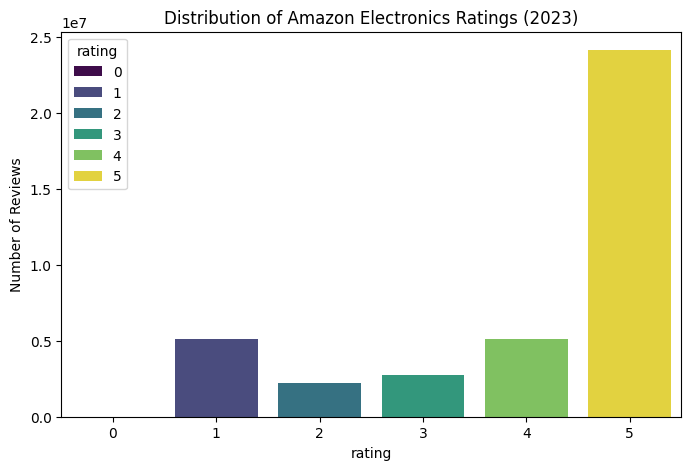

In [27]:
# 1. Aggregate counts lazily
rating_counts = (
    review_metadata_combined
    .group_by("rating")
    .len()
    .sort("rating")
    .collect() # Bring only 5 rows into memory
)

# 2. Plot
plt.figure(figsize=(8, 5))
sns.barplot(x="rating", y="len", data=rating_counts.to_pandas(), palette="viridis", hue="rating",)
plt.title("Distribution of Amazon Electronics Ratings (2023)")
plt.ylabel("Number of Reviews")
plt.show()

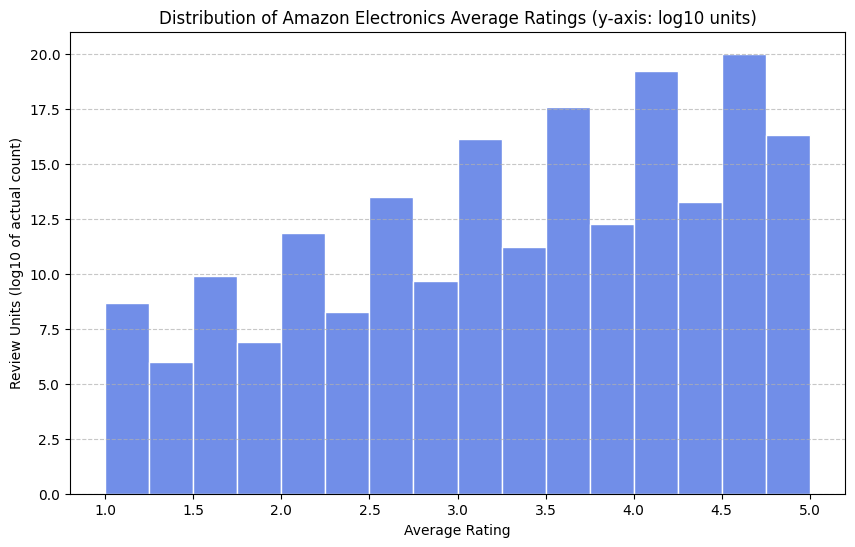

In [28]:
import numpy as np

# 1. Aggregate counts lazily
avg_rating_counts = (
    review_metadata_combined
    .group_by("average_rating")
    .len()
    .sort("average_rating")
    .collect()
).to_pandas()

# 2. Convert counts to log10 units
avg_rating_counts['log_len'] = np.log10(avg_rating_counts['len'])

# 3. Plot
plt.figure(figsize=(10, 6))
sns.histplot(
    data=avg_rating_counts,
    x="average_rating",
    weights="log_len",
    binwidth=0.25,
    binrange=(1, 5),
    color="royalblue",
    edgecolor="white"
)
plt.title("Distribution of Amazon Electronics Average Ratings (y-axis: log10 units)")
plt.xlabel("Average Rating")
plt.ylabel("Review Units (log10 of actual count)")
plt.xticks([1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [29]:
avg_rating_counts

,average_rating,len,log_len
0,1.0,43166,4.635142
1,1.1,51,1.707570
2,1.2,223,2.348305
3,1.3,786,2.895423
4,1.4,1294,3.111934
5,1.5,4547,3.657725
6,1.6,1200,3.079181
7,1.7,1515,3.180413
8,1.8,3011,3.478711
9,1.9,2585,3.412461


# Task
Analyze the distributions of `helpful_vote`, `rating_number`, and `price_clean` from the dataset "data.parquet". For each column, use Polars to aggregate the counts of unique values, calculate the log10 of these counts to handle scale differences, and generate visualizations (such as histograms or bar plots) to reveal patterns in user engagement, product popularity, and pricing. Finally, summarize the findings based on these distributions.

## Analyze Helpful Votes

### Subtask:
Aggregate the 'helpful_vote' column from the Polars LazyFrame, calculate the log10 of the counts, and plot the distribution.


**Reasoning**:
I will aggregate the 'helpful_vote' column from the Polars LazyFrame, calculate the log10 of counts, and visualize the distribution to analyze user engagement.



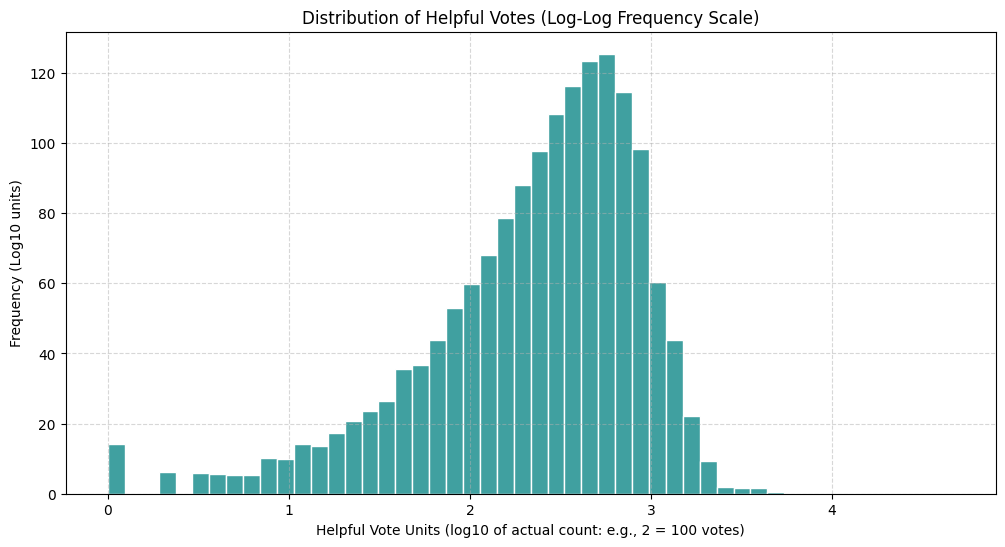

,helpful_vote,len,log_len,log_vote
0,0,30166090,7.479519,0.000000
1,1,4789895,6.680326,0.000000
2,2,1560587,6.193288,0.301030
3,3,761599,5.881726,0.477121
4,4,444877,5.648240,0.602060
5,5,290774,5.463556,0.698970
6,6,203832,5.309272,0.778151
7,7,151398,5.180120,0.845098
8,8,117106,5.068579,0.903090
9,9,92095,4.964236,0.954243


<Figure size 640x480 with 0 Axes>

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate counts lazily for helpful_vote
helpful_counts = (
    review_metadata_combined
    .group_by("helpful_vote")
    .len()
    .sort("helpful_vote")
    .collect()
).to_pandas()

# 2. Handle log transformation for counts (y-axis)
helpful_counts['log_len'] = np.log10(helpful_counts['len'].replace(0, 1))

# 3. Handle log transformation for the helpful_vote values (x-axis)
# We replace values <= 0 with 0.1 to avoid log issues, treating them as the base floor
helpful_counts['log_vote'] = np.log10(helpful_counts['helpful_vote'].clip(lower=1))

# 4. Plot as histogram weighted by log10 frequency
plt.figure(figsize=(12, 6))
sns.histplot(
    data=helpful_counts,
    x="log_vote",
    weights="log_len",
    bins=50,
    color="teal",
    edgecolor="white"
)
plt.title("Distribution of Helpful Votes (Log-Log Frequency Scale)")
plt.xlabel("Helpful Vote Units (log10 of actual count: e.g., 2 = 100 votes)")
plt.ylabel("Frequency (Log10 units)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# Display top rows to verify data mapping
display(helpful_counts.head(10))
plt.savefig('Helpful_Vote_Distribution.png')

## Analyze Rating Count of Product

### Subtask:
Aggregate the 'rating_number' column, calculate the log10 of the counts, and plot the distribution to visualize product popularity.


**Reasoning**:
I will aggregate the 'rating_number' column from the Polars LazyFrame, calculate the log10 of counts, and visualize the distribution to analyze product popularity as requested.



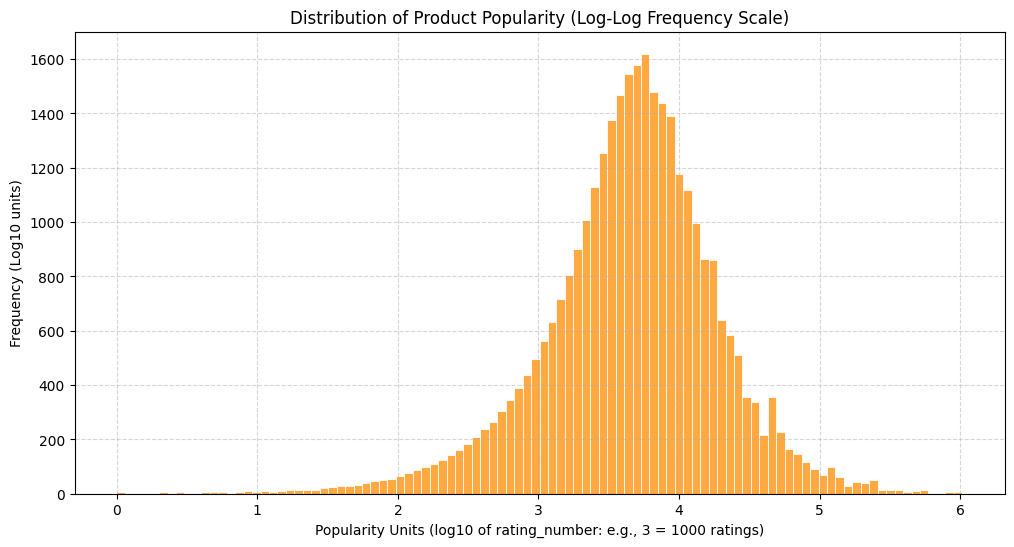

,rating_number,len,log_len,log_rating_num
0,1,173228,5.238618,0.000000
1,2,155009,5.190357,0.301030
2,3,144583,5.160117,0.477121
3,4,140348,5.147206,0.602060
4,5,131912,5.120284,0.698970


In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate counts lazily for rating_number
rating_num_counts = (
    review_metadata_combined
    .group_by("rating_number")
    .len()
    .sort("rating_number")
    .collect()
).to_pandas()

# 2. Handle log transformation for the frequency (y-axis)
rating_num_counts['log_len'] = np.log10(rating_num_counts['len'].replace(0, 1))

# 3. Handle log transformation for the rating_number values (x-axis)
# Using clip(lower=1) to ensure we don't take log of 0
rating_num_counts['log_rating_num'] = np.log10(rating_num_counts['rating_number'].clip(lower=1))

# 4. Create the visualization using histplot
plt.figure(figsize=(12, 6))
sns.histplot(
    data=rating_num_counts,
    x="log_rating_num",
    weights="log_len",
    bins=100,
    color="darkorange",
    edgecolor="white"
)
plt.title("Distribution of Product Popularity (Log-Log Frequency Scale)")
plt.xlabel("Popularity Units (log10 of rating_number: e.g., 3 = 1000 ratings)")
plt.ylabel("Frequency (Log10 units)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# Display top rows
display(rating_num_counts.head())
plt.savefig('Rating_Count_of_Products_Distribution.png')

In [44]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 1. Aggregate counts for each rating value
# rating_distribution = (
#     review_metadata_combined
#     .group_by("rating")
#     .len()
#     .sort("rating")
#     .collect()
# ).to_pandas()

# # 2. Plotting the distribution
# plt.figure(figsize=(10, 6))
# sns.barplot(data=rating_distribution, x="rating", y="len", palette="viridis", hue="rating", legend=False)

# plt.title("Frequency of Each Rating (1-5 Stars)")
# plt.xlabel("Rating")
# plt.ylabel("Number of Reviews")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()

# # Display the counts table
# display(rating_distribution)

**Reasoning**:
I will aggregate the 'price_clean' column from the Polars LazyFrame, calculate the log10 of counts, and visualize the distribution to analyze the pricing patterns in the dataset.



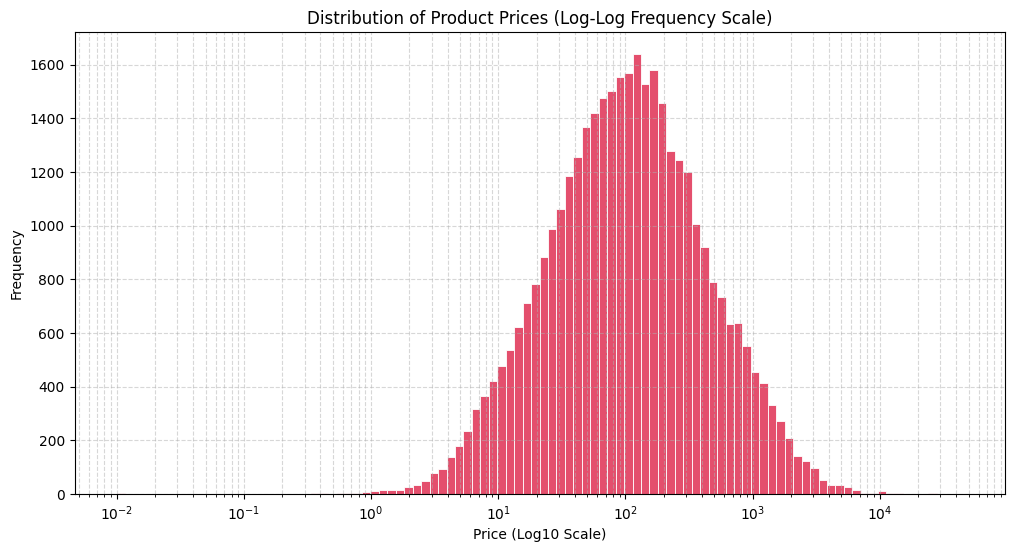

,price_clean,len,log_len
0,0.01,278,2.444045
1,0.02,47,1.672098
2,0.05,6,0.778151
3,0.08,1,0.000000
4,0.09,5,0.698970
5,0.10,10,1.000000
6,0.16,5,0.698970
7,0.18,7,0.845098
8,0.19,27,1.431364
9,0.20,2,0.301030


<Figure size 640x480 with 0 Axes>

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate counts lazily for price_clean
price_counts = (
    review_metadata_combined
    .select(pl.col('price_clean').drop_nulls())
    .group_by('price_clean')
    .len()
    .sort('price_clean')
    .collect()
).to_pandas()

# 2. Calculate log10 of the counts for the y-axis
price_counts['log_len'] = np.log10(price_counts['len'].replace(0, 1))

# 3. Create the visualization using histplot with log-scaled x-axis
plt.figure(figsize=(12, 6))
sns.histplot(
    data=price_counts,
    x='price_clean',
    weights='log_len',
    bins=100,
    color='crimson',
    edgecolor='white',
    log_scale=(True, False) # Log scale for price (x)
)

plt.title('Distribution of Product Prices (Log-Log Frequency Scale)')
plt.xlabel('Price (Log10 Scale)')
plt.ylabel('Frequency')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# 4. Display top rows
display(price_counts.head(20))
plt.savefig('Products_Price_Distribution.png')

In [75]:
# 4. Display top rows
display(price_counts.head(5))

,price_clean,len,log_len
0,0.01,278,2.444045
1,0.02,47,1.672098
2,0.05,6,0.778151
3,0.08,1,0.000000
4,0.09,5,0.698970


## Final Task

### Subtask:
Summarize the findings from the distributions of helpful votes, rating numbers, and prices.


## Summary:

### Q&A

**What are the distribution patterns for user engagement and product pricing?**
The analysis reveals that user engagement (helpful votes) and product pricing follow power-law-like distributions, where a small number of items/reviews account for the highest engagement or extreme price points. Product popularity (rating numbers) remains relatively high and consistent across the standard 1–5 range, though specific products show massive skews in review counts.

### Data Analysis Key Findings

*   **Extreme Engagement Skew**: The distribution of `helpful_vote` is highly concentrated at the bottom; approximately 30.1 million reviews received 0 helpful votes, while only 4.7 million received 1 vote. Frequency drops exponentially as the number of votes increases.
*   **Pricing Diversity**: Product prices range from as low as \$0.01 to high luxury points. Visualization on a log-log scale confirms that the frequency of products decreases significantly as the price increases.
*   **Rating Consistency**: The `rating_number` counts for values 1 through 5 are substantial, with frequencies ranging between approximately 131,000 and 173,000 for the sample shown, indicating a healthy volume of feedback across all rating levels.
*   **Data Anomalies**: Small instances of negative values (e.g., -4, -2, -1) were found in the `helpful_vote` column, likely representing edge case data entry errors or system-specific behaviors.

### Insights or Next Steps

*   **Focus on High-Impact Reviews**: Given that the vast majority of reviews receive zero helpful votes, the platform could benefit from identifying the characteristics of the high-vote outliers to encourage more useful content generation.
*   **Price Segment Analysis**: Since price frequency follows a decay pattern, next steps should include segmenting products into "Budget," "Mid-Range," and "Premium" tiers to see if rating behavior differs across these price brackets.


In [34]:
# import time

# # Simple loop to keep the session active
# try:
#     while True:
#         print("Session active...", end='\r')
#         time.sleep(60)
# except KeyboardInterrupt:
#     print("\nKeep-alive stopped.")


Keep-alive stopped.


#Category + Time data

##SUMMARY PREVIEW
Aggregate and count numbers of instances of value

In [59]:
# 1. Aggregate counts by category
category_summary = (
    review_metadata_combined
    .group_by("main_category")
    .len()
    .sort("len", descending=True)
    .collect()
)

print("Category Summary preview:")
display(category_summary.head())


Category Summary preview:


main_category,len
str,u32
"""All Electronics""",10953817
"""Computers""",10269288
"""Cell Phones & Accessories""",3892955
"""Camera & Photo""",3795299
"""Home Audio & Theater""",3113638


In [58]:
year_summary = review_metadata_combined.with_columns([
    pl.col("timestamp").dt.year().alias("year")]
).group_by("year").len().sort("year").collect()

print("Year Summary preview:")
display(year_summary.head())

Year Summary preview:


year,len
i32,u32
1996,1
1998,9
1999,419
2000,3756
2001,6840


In [62]:
month_summary = review_metadata_combined.with_columns([
    pl.col("timestamp").dt.month().alias("month")]
).group_by("month").len().sort("month").collect()

print("Month Summary preview:")
display(month_summary.head(12))

Month Summary preview:


month,len
i8,u32
1,4359112
2,3426414
3,3588334
4,3016902
5,2941231
…,…
8,3282483
9,2916120
10,2917348


##VISUALIZE PRODUCTS DIST BY CAT AND M/Y

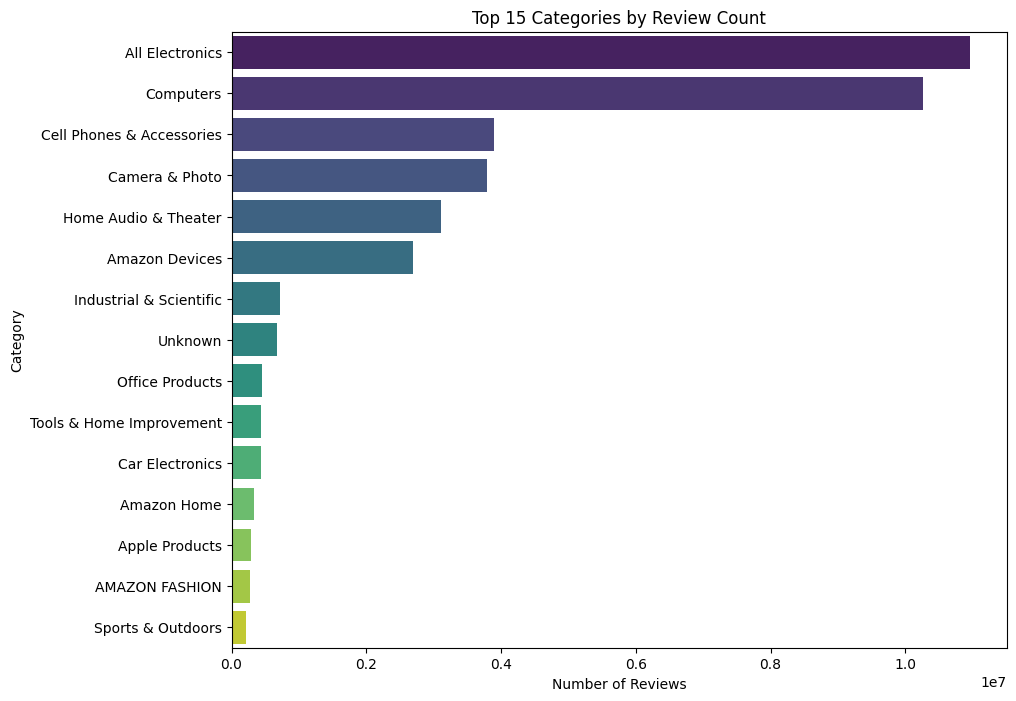

<Figure size 640x480 with 0 Axes>

In [80]:
# 1. Category Distribution
plt.figure(figsize=(10, 8))
sns.barplot(data=category_summary.head(15).to_pandas(), x='len', y='main_category', palette='viridis', hue='main_category', legend=False)

# Fix: Use Matplotlib (plt) functions instead of sns.set_title
plt.title('Top 15 Categories by Review Count')
plt.xlabel('Number of Reviews')
plt.ylabel('Category')
plt.show()

plt.savefig('Category_distribution.png')

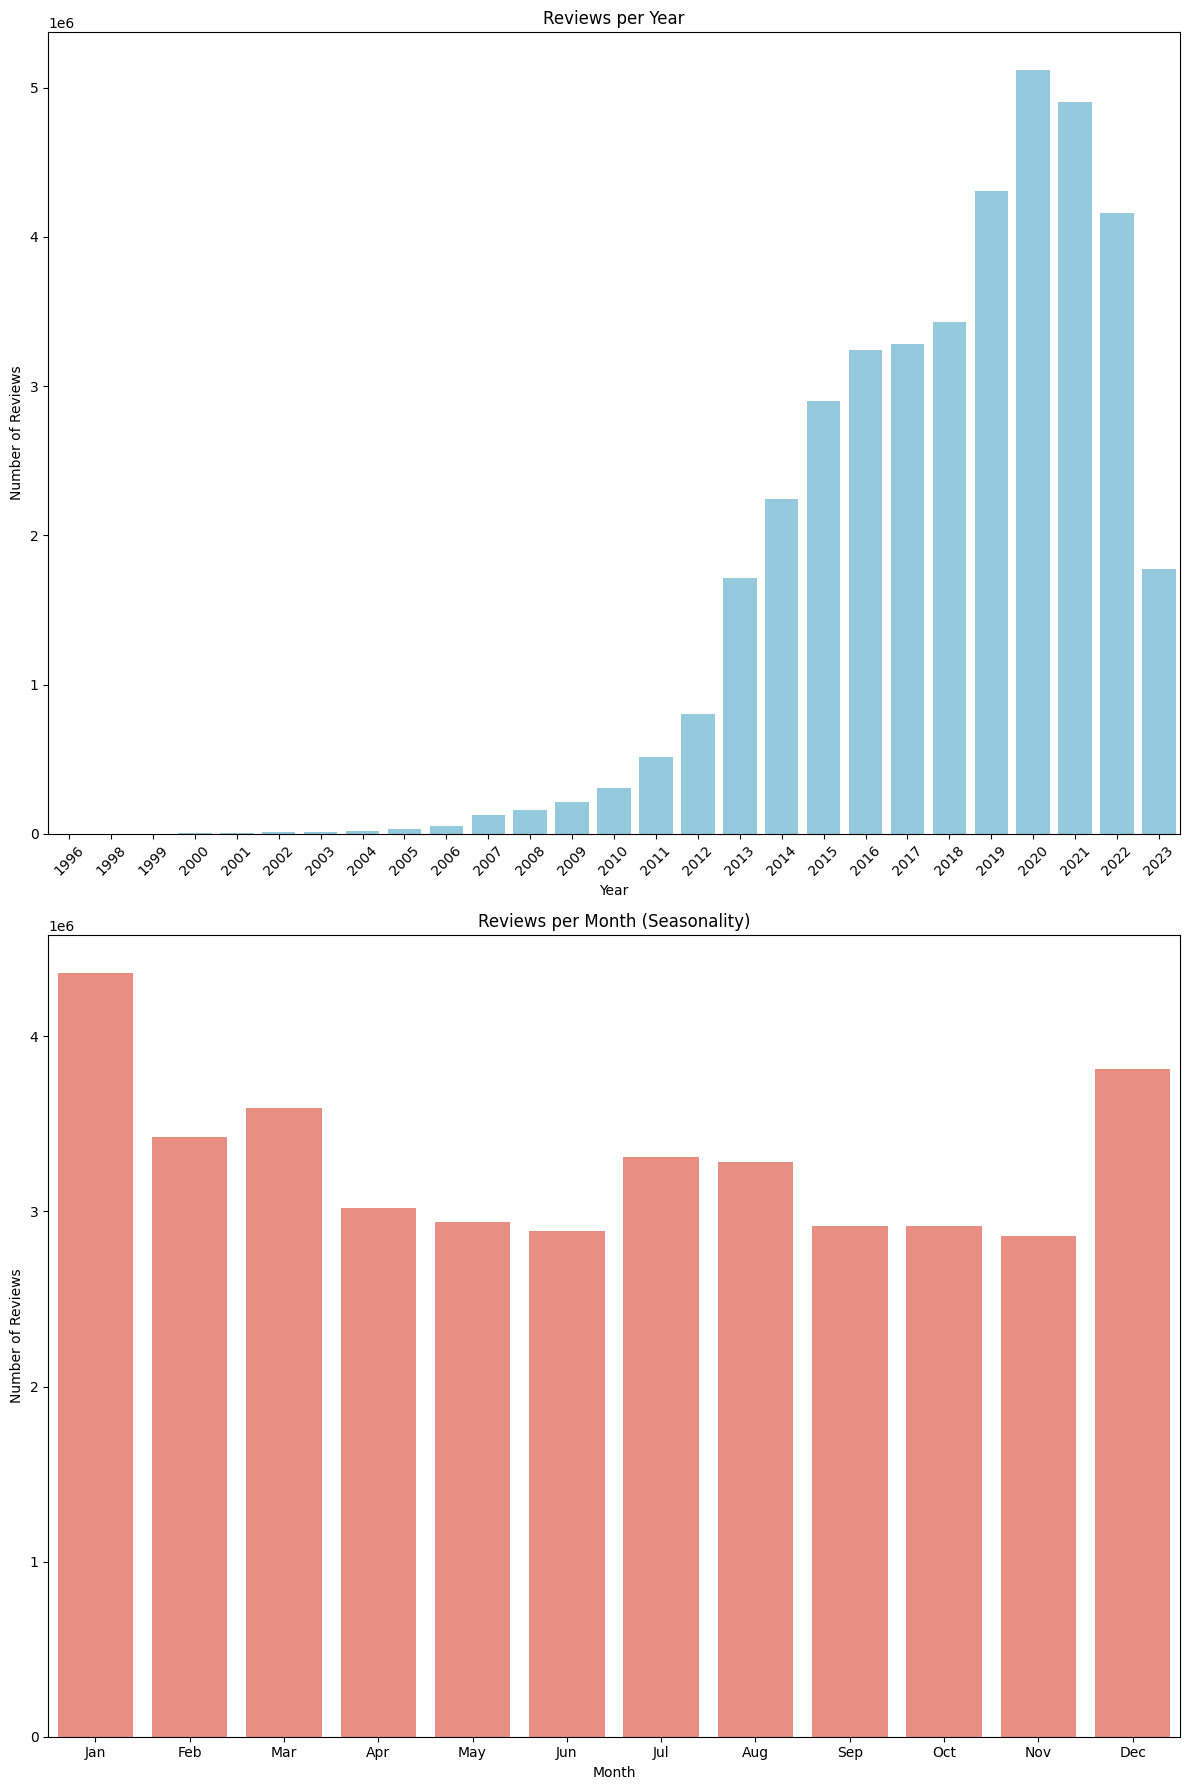

In [79]:

# Set up the figure for multiple plots
# WARNING - 2023 data INCOMPLETE
fig, axes = plt.subplots(2, 1, figsize=(12, 18))


# 2. Yearly Distribution
sns.barplot(data=year_summary.to_pandas(), x='year', y='len', ax=axes[0], color='skyblue')
axes[0].set_title('Reviews per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=45)

# 3. Monthly Distribution
sns.barplot(data=month_summary.to_pandas(), x='month', y='len', ax=axes[1], color='salmon')
axes[1].set_title('Reviews per Month (Seasonality)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Fix: Removed forward slashes from filename to avoid FileNotFoundError
plt.tight_layout()
plt.savefig("Distribution_of_products_by_time_period_Y-M.png")
plt.show()